# CH 5 - 5 : DUELING HYPOTHESES - THE NULL HYPOTHESIS VERSUS THE ALTERNATIVE HYPOTHESIS

## Objectif pédagogique

Ce cahier transforme le concept du duel entre l’**Hypothèse Nulle** ($H_0$) et l’**Hypothèse Alternative** ($H_A$) en exemple concret de trading EBTA.

L’idée centrale est simple :

> En EBTA, on ne commence pas par croire qu’une règle de trading fonctionne.  
> On commence par supposer qu’elle ne vaut rien, puis on demande aux données de fournir une preuve assez forte pour rejeter cette supposition.

Dans ce cadre :

- $H_0$ : la règle n’a pas de pouvoir prédictif réel.
- $H_A$ : la règle possède un avantage statistique réel.
- Le test statistique ne prouve pas directement $H_A$.
- Il tente de falsifier $H_0$.

## 1. Le duel logique : $H_0$ contre $H_A$

Pour une stratégie de trading, on peut définir :

$$H_0 : \mu \le 0$$

$$H_A : \mu > 0$$

où $\mu$ représente le rendement moyen attendu de la règle sur des données correctement préparées.

### Interprétation

- Si $\mu \le 0$, la stratégie n’a pas de valeur exploitable.
- Si $\mu > 0$, la stratégie possède potentiellement un edge.
- Il n’y a pas de troisième option : soit le rendement attendu est nul/négatif, soit il est positif.

Les deux hypothèses sont donc :

1. **Mutuellement exclusives** : elles ne peuvent pas être vraies en même temps.
2. **Exhaustives** : elles couvrent tous les cas possibles.

## 2. Pourquoi tester $H_0$ plutôt que $H_A$ ?

$H_A$ contient une infinité de possibilités :

- $\mu = 0.01\%$
- $\mu = 0.10\%$
- $\mu = 1.00\%$
- $\mu = 5.00\%$
- etc.

Il est donc difficile de tester directement toutes les valeurs positives possibles.

En revanche, $H_0$ peut être ramenée à son cas le plus favorable :

$$\mu = 0$$

Si le résultat observé est déjà très improbable lorsque la règle a une espérance nulle, alors il est encore moins compatible avec une règle négative.

C’est pour cela que la distribution d’échantillonnage est souvent centrée sur zéro dans les tests EBTA.

## 3. Analogie du procès

On peut comparer le test d’hypothèse à un procès :

| Élément du procès | Équivalent EBTA |
|---|---|
| Accusé | La stratégie de trading |
| Présomption d’innocence | La stratégie n’a aucun talent |
| Hypothèse nulle | $H_0 : \mu \le 0$ |
| Preuves | Les profits observés en backtest |
| Jury | Le test statistique |
| Verdict | Rejet ou non-rejet de $H_0$ |

Important : si les preuves sont faibles, on ne dit pas que $H_0$ est vraie.  
On dit simplement :

> Nous n’avons pas assez de preuves pour rejeter $H_0$.

## 4. Exemple trading : une règle avec rendement positif

Imaginons une règle de trading testée sur plusieurs jours.

Elle produit une série de rendements quotidiens.  
On veut savoir si son rendement moyen observé est suffisamment élevé pour être considéré comme improbable sous $H_0$.

Nous allons simuler trois cas :

1. Une règle sans edge.
2. Une règle avec un petit edge.
3. Une règle avec un edge plus clair.

Puis nous allons comparer les p-values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

def simulate_strategy(n_days=500, true_daily_edge=0.0, daily_vol=0.01):
    # Simule les rendements quotidiens d'une stratégie.
    returns = np.random.normal(loc=true_daily_edge, scale=daily_vol, size=n_days)
    return returns

cases = {
    "Sans edge": simulate_strategy(true_daily_edge=0.0000),
    "Petit edge": simulate_strategy(true_daily_edge=0.0004),
    "Edge plus clair": simulate_strategy(true_daily_edge=0.0008),
}

summary = []

for name, returns in cases.items():
    mean_return = returns.mean()
    std_return = returns.std(ddof=1)
    n = len(returns)

    # Test unilatéral à droite :
    # H0 : mu <= 0
    # HA : mu > 0
    t_stat = mean_return / (std_return / np.sqrt(n))
    p_value = 1 - stats.t.cdf(t_stat, df=n-1)

    summary.append({
        "Cas": name,
        "Rendement moyen quotidien": mean_return,
        "Rendement annualisé approx.": mean_return * 252,
        "t-stat": t_stat,
        "p-value": p_value,
        "Décision à 5%": "Rejet de H0" if p_value < 0.05 else "Non-rejet de H0"
    })

df_summary = pd.DataFrame(summary)
df_summary

,Cas,Rendement moyen quotidien,Rendement annualisé approx.,t-stat,p-value,Décision à 5%
0,Sans edge,0.000068,0.017232,0.155823,0.438118,Non-rejet de H0
1,Petit edge,0.000718,0.181002,1.642214,0.050588,Non-rejet de H0
2,Edge plus clair,0.001885,0.474981,4.171896,0.000018,Rejet de H0


## 5. Lecture du tableau

La p-value répond à cette question :

> Si la stratégie n’avait réellement aucun edge, quelle serait la probabilité d’observer un résultat au moins aussi bon que celui-ci par simple chance ?

Donc :

- p-value élevée : le résultat est compatible avec la chance.
- p-value faible : le résultat devient difficile à expliquer par la chance seule.
- p-value < 0,05 : on rejette généralement $H_0$.

Mais attention :

> Rejeter $H_0$ ne veut pas dire que la stratégie est garantie rentable.  
> Cela veut dire que le résultat observé est suffisamment incompatible avec l’hypothèse “aucun edge”.

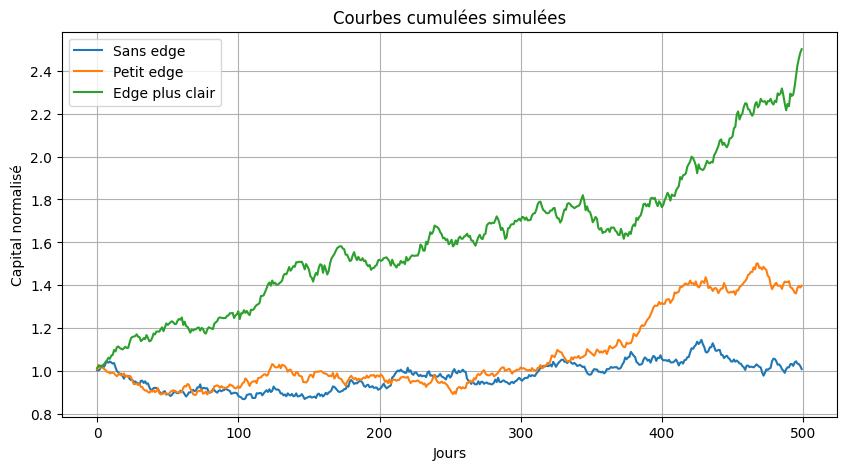

In [2]:
# Visualisation des rendements cumulés

plt.figure(figsize=(10, 5))

for name, returns in cases.items():
    equity_curve = (1 + returns).cumprod()
    plt.plot(equity_curve, label=name)

plt.title("Courbes cumulées simulées")
plt.xlabel("Jours")
plt.ylabel("Capital normalisé")
plt.legend()
plt.grid(True)
plt.show()

## 6. Visualiser la distribution sous $H_0$

Maintenant, on va construire une distribution d’échantillonnage sous l’hypothèse nulle.

Sous $H_0$, on suppose que :

$$\mu = 0$$

On simule donc beaucoup de backtests fictifs de règles sans edge, puis on observe la distribution des rendements moyens obtenus par hasard.

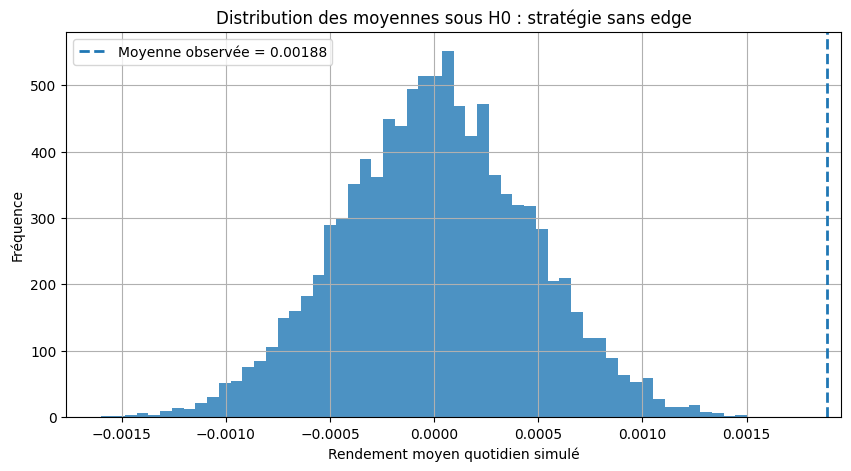

np.float64(0.0)

In [3]:
np.random.seed(123)

n_days = 500
daily_vol = 0.01
n_simulations = 10000

null_means = []

for _ in range(n_simulations):
    null_returns = np.random.normal(loc=0.0, scale=daily_vol, size=n_days)
    null_means.append(null_returns.mean())

null_means = np.array(null_means)

observed_returns = cases["Edge plus clair"]
observed_mean = observed_returns.mean()

p_value_empirical = np.mean(null_means >= observed_mean)

plt.figure(figsize=(10, 5))
plt.hist(null_means, bins=60, alpha=0.8)
plt.axvline(observed_mean, linestyle="--", linewidth=2, label=f"Moyenne observée = {observed_mean:.5f}")
plt.title("Distribution des moyennes sous H0 : stratégie sans edge")
plt.xlabel("Rendement moyen quotidien simulé")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.show()

p_value_empirical

## 7. Interprétation du graphique

Le graphique montre ce qui peut arriver par hasard si $H_0$ est vraie.

La ligne verticale représente le rendement moyen observé de la stratégie testée.

Si cette ligne tombe très loin dans la queue droite de la distribution, cela signifie :

> Ce résultat serait rare si la stratégie n’avait aucun edge.

C’est exactement la logique de falsification :

1. Supposons que $H_0$ soit vraie.
2. Sous cette supposition, le résultat observé devrait être ordinaire.
3. Or le résultat observé est très rare.
4. Donc $H_0$ devient difficile à défendre.

## 8. Version EBTA : fonction de décision

On peut maintenant écrire une fonction simple qui applique la logique EBTA :

- Entrée : rendements d’une stratégie.
- Hypothèse testée : $H_0 : \mu \le 0$.
- Alternative : $H_A : \mu > 0$.
- Sortie : p-value et décision.

In [4]:
def ebta_hypothesis_test(returns, alpha=0.05):
    # Test EBTA simplifié pour une stratégie de trading.
    # H0 : rendement moyen <= 0
    # HA : rendement moyen > 0

    returns = np.asarray(returns)
    n = len(returns)
    mean_return = returns.mean()
    std_return = returns.std(ddof=1)

    t_stat = mean_return / (std_return / np.sqrt(n))
    p_value = 1 - stats.t.cdf(t_stat, df=n-1)

    decision = "Rejeter H0 : preuve statistique d'un edge" if p_value < alpha else "Ne pas rejeter H0 : preuve insuffisante"

    return {
        "n_observations": n,
        "mean_daily_return": mean_return,
        "annualized_return_approx": mean_return * 252,
        "t_stat": t_stat,
        "p_value": p_value,
        "alpha": alpha,
        "decision": decision
    }

for name, returns in cases.items():
    print("\n", name)
    result = ebta_hypothesis_test(returns)
    for key, value in result.items():
        print(f"{key}: {value}")


 Sans edge
n_observations: 500
mean_daily_return: 6.837994588647588e-05
annualized_return_approx: 0.01723174636339192
t_stat: 0.15582338984457086
p_value: 0.4381176244772218
alpha: 0.05
decision: Ne pas rejeter H0 : preuve insuffisante

 Petit edge
n_observations: 500
mean_daily_return: 0.0007182611705600343
annualized_return_approx: 0.18100181498112863
t_stat: 1.6422141197272513
p_value: 0.050587819286124325
alpha: 0.05
decision: Ne pas rejeter H0 : preuve insuffisante

 Edge plus clair
n_observations: 500
mean_daily_return: 0.0018848452984028445
annualized_return_approx: 0.47498101519751684
t_stat: 4.171895532587619
p_value: 1.781561384983643e-05
alpha: 0.05
decision: Rejeter H0 : preuve statistique d'un edge


## 9. Ce qu’il faut retenir pour ton protocole EBTA

### Règle mentale

Ne dis pas :

> Ma stratégie a gagné en backtest, donc elle marche.

Dis plutôt :

> Si ma stratégie n’avait aucun edge, quelle serait la probabilité d’obtenir un backtest aussi bon par hasard ?

Cette inversion change tout.

Elle force le trader à quitter la croyance et à entrer dans une logique scientifique.

### Checklist EBTA

Avant de valider une règle :

1. Définir clairement le paramètre testé : rendement moyen, Sharpe, profit factor, etc.
2. Définir $H_0$ : absence d’avantage.
3. Définir $H_A$ : présence d’un avantage.
4. Vérifier que les deux hypothèses sont exclusives et exhaustives.
5. Construire une distribution sous $H_0$.
6. Calculer la p-value.
7. Rejeter $H_0$ seulement si le résultat est suffisamment improbable.
8. Ne jamais confondre rejet de $H_0$ avec certitude absolue.

## 10. Résumé final

Le duel entre $H_0$ et $H_A$ est le cœur logique du test statistique en trading.

- $H_0$ représente le scepticisme : la stratégie n’a aucun talent.
- $H_A$ représente l’edge : la stratégie a un pouvoir prédictif réel.
- Le test ne prouve pas directement $H_A$.
- Il cherche à rendre $H_0$ intenable.
- Une p-value faible signifie que le résultat observé serait rare sous $H_0$.
- Si la preuve est faible, on conserve la posture sceptique.

En EBTA, une stratégie ne gagne pas le droit d’être crue parce qu’elle est séduisante.  
Elle gagne ce droit seulement si elle survit à l’épreuve de la falsification statistique.